# RCNN decoder — failure-case explorer (d=5, p=0.010, r=3)

**Motivating question:** *"What does the circuit look like when it's giving a lot of error?"*

This notebook pulls out the shots where the compact RCNN decoder gets the logical class
**wrong**, and — for the scientifically interesting subset where **MWPM gets it right but the
RCNN doesn't** (the McNemar-discordant shots) — shows the actual physical error chain on the
surface-code lattice, interactively, via **Crumble**.

Per-shot data comes from `eval_on_tail.py --dump-per-shot` on the 10M-shot model
(`out_t200k_w/…seed0…`), scored on the fixed 200k tail. Sanity-checked below: RCNN
p_L ≈ 0.046, MWPM p_L ≈ 0.049 (RCNN beats MWPM by ~0.94×), matching the benchmark.

Sections:
1. Setup + sanity
2. Failure populations + ranked table of discordant shots
3. **Single-shot deep dive** — physical error chain + inline Crumble (the main figure for the collaborator)
4. Browse: Crumble links for the top-K most-confidently-wrong shots
5. Aggregate: which detectors / lattice regions fail most often


## 1 · Setup + sanity

In [12]:
import numpy as np, stim, pymatching
import matplotlib.pyplot as plt
from IPython.display import display, IFrame, Markdown

# --- config: must match how the pool + dump were generated ---
D, P, R = 5, 0.010, 3
DUMP = "/Users/karriechey/rcnn_threshold/pershot_d5_r3_seed0_10M.npz"

from circuit_generators import get_builtin_circuit
CIRC = get_builtin_circuit(
    'surface_code:rotated_memory_z', distance=D, rounds=R,
    before_round_data_depolarization=P, after_reset_flip_probability=P,
    after_clifford_depolarization=P, before_measure_flip_probability=P)
DEM = CIRC.detector_error_model(decompose_errors=True)      # decompose -> matchable
MATCH = pymatching.Matching.from_detector_error_model(DEM)
DET_COORDS = CIRC.get_detector_coordinates()                # det_id -> [x, y, round]
print(f"circuit: {CIRC.num_detectors} detectors, {CIRC.num_observables} observable(s)")


circuit: 72 detectors, 1 observable(s)


In [13]:
z = np.load(DUMP)
det_evts    = z['det_evts'].astype(np.uint8)      # (n_tail, 72) syndromes
truth       = z['truth'].astype(int)              # true logical flip
rcnn_pred   = z['rcnn_pred'].astype(int)
rcnn_prob   = z['rcnn_prob'].astype(float)        # raw sigmoid
rcnn_ok     = z['rcnn_correct'].astype(bool)
mwpm_pred   = z['mwpm_pred'].astype(int)
mwpm_ok     = z['mwpm_correct'].astype(bool)
tail_idx    = z['tail_idx']                        # indices into the 10M pool
n = det_evts.shape[0]

print(f"n_tail = {n:,}")
print(f"RCNN  p_L = {(~rcnn_ok).mean():.5f}   (expect ~0.046)")
print(f"MWPM  p_L = {(~mwpm_ok).mean():.5f}   (expect ~0.049)")
print(f"ratio RCNN/MWPM = {(~rcnn_ok).mean()/(~mwpm_ok).mean():.3f}x  (<1 => RCNN wins)")
assert det_evts.shape[1] == CIRC.num_detectors, "detector count mismatch pool vs circuit!"


n_tail = 200,000
RCNN  p_L = 0.04596   (expect ~0.046)
MWPM  p_L = 0.04870   (expect ~0.049)
ratio RCNN/MWPM = 0.944x  (<1 => RCNN wins)


## 2 · Failure populations

The paired 2×2 vs MWPM on the shared tail. The **discordant** cell we care about is
`RCNN-wrong & MWPM-right` — those are the shots where the compact decoder specifically
struggles while optimal matching succeeds.

In [14]:
both_right = rcnn_ok & mwpm_ok
rcnn_only  = rcnn_ok & ~mwpm_ok          # RCNN wins
mwpm_only  = ~rcnn_ok & mwpm_ok          # <-- DISCORDANT: RCNN wrong, MWPM right
both_wrong = ~rcnn_ok & ~mwpm_ok
for name, mask in [('both-right',both_right),('RCNN-only (RCNN wins)',rcnn_only),
                   ('MWPM-only (RCNN wrong, MWPM right)',mwpm_only),('both-wrong',both_wrong)]:
    print(f"{name:38s} {int(mask.sum()):>7,}")
print(f"\nRCNN-wrong total (for aggregate view) = {int((~rcnn_ok).sum()):,}")
print(f"discordant (for spot-checks)          = {int(mwpm_only.sum()):,}")


both-right                             187,187
RCNN-only (RCNN wins)                    3,622
MWPM-only (RCNN wrong, MWPM right)       3,074
both-wrong                               6,117

RCNN-wrong total (for aggregate view) = 9,191
discordant (for spot-checks)          = 3,074


In [15]:
import pandas as pd
# rank discordant shots by how CONFIDENTLY the RCNN was wrong (|prob-0.5| on the wrong side),
# then by how many detectors fired. "Confidently wrong" shots are the most telling.
disc = np.where(mwpm_only)[0]
rows = pd.DataFrame({
    'shot': disc,
    'pool_idx': tail_idx[disc],
    'n_det_fired': det_evts[disc].sum(1),
    'truth': truth[disc],
    'rcnn_pred': rcnn_pred[disc],
    'rcnn_prob': rcnn_prob[disc].round(3),
    'wrong_confidence': np.abs(rcnn_prob[disc]-0.5).round(3),  # bigger = more confidently wrong
})
rows = rows.sort_values(['wrong_confidence','n_det_fired'], ascending=False).reset_index(drop=True)
print(f"{len(rows):,} discordant shots. Top 20 most-confidently-wrong:")
rows.head(20)


3,074 discordant shots. Top 20 most-confidently-wrong:


,shot,pool_idx,n_det_fired,truth,rcnn_pred,rcnn_prob,wrong_confidence
0,64684,9874684,14,1,0,0.010,0.490
1,49639,9859639,11,0,1,0.989,0.489
2,111990,9921990,15,1,0,0.018,0.482
3,47012,9857012,9,0,1,0.981,0.481
4,12756,9822756,17,0,1,0.979,0.479
5,165315,9975315,14,1,0,0.021,0.479
6,14091,9824091,10,0,1,0.979,0.479
7,173280,9983280,8,1,0,0.021,0.479
8,122771,9932771,16,1,0,0.023,0.477
9,68268,9878268,15,1,0,0.023,0.477


## 3 · Single-shot deep dive — the physical error chain

For a chosen shot we:
1. list the **fired detectors** (with lattice coords `x, y, round`),
2. use MWPM's matching to get the representative **physical error mechanisms** consistent
   with that syndrome — the actual `X/Y/Z` errors on specific qubits at specific rounds
   (`stim.Circuit.explain_detector_error_model_errors`),
3. drop that error chain into **Crumble**, highlighted and propagated forward.

Crumble is dense for d=5 over 3 rounds, so this is a "look closely at one interesting shot"
tool. Change `SHOT` to any value from the table above.

In [16]:
def physical_error_chain(shot):
    """Return (edges, explained_errors, readable_rows) for one shot's syndrome."""
    syn = det_evts[shot].astype(np.uint8)
    edges = MATCH.decode_to_edges_array(syn)           # detector pairs; -1 = boundary
    lines = [f'error(1) D{a} L0' if b == -1 else f'error(1) D{a} D{b}' for a, b in edges]
    expl = CIRC.explain_detector_error_model_errors(
        dem_filter=stim.DetectorErrorModel("\n".join(lines)),
        reduce_to_one_representative_error=True)
    marks = [e for e in expl if e.circuit_error_locations]   # keep only resolvable errors
    readable = []
    for e in marks:
        loc = e.circuit_error_locations[0]
        dets = [f"D{t.dem_target.val}" for t in e.dem_error_terms if t.dem_target.is_relative_detector_id()]
        for g in loc.flipped_pauli_product:
            pauli = 'X' if g.gate_target.is_x_target else 'Y' if g.gate_target.is_y_target else 'Z'
            readable.append(dict(qubit=g.gate_target.value, coords=tuple(g.coords),
                                 pauli=pauli, tick_offset=loc.tick_offset,
                                 lights=" ".join(dets)))
    return edges, marks, pd.DataFrame(readable)

def fired_detectors(shot):
    ids = np.where(det_evts[shot])[0]
    return pd.DataFrame([dict(det=i, x=DET_COORDS[i][0], y=DET_COORDS[i][1],
                              round=int(DET_COORDS[i][2])) for i in ids])


In [17]:
SHOT = int(rows.iloc[0]['shot'])   # most-confidently-wrong discordant shot; change freely

print(f"shot {SHOT}  (pool idx {tail_idx[SHOT]})")
print(f"  truth (true logical flip) = {truth[SHOT]}")
print(f"  RCNN predicted {rcnn_pred[SHOT]} (prob {rcnn_prob[SHOT]:.3f})  -> {'WRONG' if not rcnn_ok[SHOT] else 'right'}")
print(f"  MWPM predicted {mwpm_pred[SHOT]}                     -> {'right' if mwpm_ok[SHOT] else 'WRONG'}")
print(f"  {int(det_evts[SHOT].sum())} detectors fired")
display(Markdown("**Fired detectors (x, y, round):**"))
display(fired_detectors(SHOT))


shot 64684  (pool idx 9874684)
  truth (true logical flip) = 1
  RCNN predicted 0 (prob 0.010)  -> WRONG
  MWPM predicted 1                     -> right
  14 detectors fired


**Fired detectors (x, y, round):**

,det,x,y,round
0,14,2.0,2.0,1
1,15,4.0,2.0,1
2,22,6.0,4.0,1
3,23,8.0,4.0,1
4,25,4.0,6.0,1
5,26,6.0,6.0,1
6,27,8.0,6.0,1
7,38,2.0,2.0,2
8,45,4.0,4.0,2
9,46,6.0,4.0,2


In [18]:
edges, expl, chain = physical_error_chain(SHOT)
display(Markdown(f"**Representative physical error chain — {len(chain)} mechanism(s):** "
                 f"each row is a Pauli error on one qubit; `lights` = the detectors it flips."))
display(chain)


**Representative physical error chain — 6 mechanism(s):** each row is a Pauli error on one qubit; `lights` = the detectors it flips.

,qubit,coords,pauli,tick_offset,lights
0,3,"(3.0, 1.0)",X,3,D14
1,28,"(6.0, 4.0)",X,7,D22 D46
2,29,"(7.0, 5.0)",X,4,D23 D26
3,37,"(4.0, 6.0)",X,7,D25 D49
4,14,"(3.0, 3.0)",X,12,D38 D45
5,38,"(5.0, 7.0)",X,11,D50 D55


### Inline Crumble (the figure to show the collaborator)

The link opens the full circuit in **Crumble** with **this shot's error chain highlighted** and
propagated. The embedded frame below is the same thing inline.

---
#### How to read the Crumble view

**Layout & navigation.** Qubits are dots at their physical `(x, y)` positions (the rotated d=5
lattice: 25 data + 24 ancilla). Time runs in **slices** — use the slice bar / `←` `→` at the top
to step through **Tick 0 … 21**. Each tick is one layer of operations; the ticks group into the
3 QEC rounds plus initial reset and final readout.

**Operation labels (what's happening to each qubit):**

| label | meaning |
|---|---|
| `R`  | reset qubit to \|0⟩ |
| `H`  | Hadamard — rotates an ancilla into the X basis so it measures an **X**-stabilizer |
| `CX` | CNOT — entangles an ancilla with a neighboring data qubit (the diagonal links) |
| `MR` | measure **and** reset an ancilla (the per-round syndrome readout) |
| `M`  | final measurement of the data qubits |
| `DT` / `OI` | *annotations*, not gates: `DT`=DETECTOR, `OI`=OBSERVABLE_INCLUDE (the logical) |

**Noise labels = your error model, drawn where it acts (all at p = `0.01`):**

| label | Stim channel | where it comes from |
|---|---|---|
| `DEP 1` | `DEPOLARIZE1(0.01)` | before-round data depolarization (random X/Y/Z) |
| `DEP 2` | `DEPOLARIZE2(0.01)` | after every CX (`after_clifford_depolarization`) |
| `ERR x` | `X_ERROR(0.01)` | reset & pre-measurement bit-flips |

So the `DEP 1` / `DEP 2` / `ERR x` / `0.01` clutter is literally **"what can go wrong, and where"** —
the physical noise model in place.

**The colored diamonds = this shot's error chain (the point of the figure).** We injected the
shot's representative physical errors as **markers**. For shot `64684` all six are **X** errors, so
they appear as markers on the six data qubits where the error struck. Crumble then **propagates**
that Pauli frame forward through the gates — as it passes through `CX`s it spreads and can rotate
type, so downstream the marker **changes color and hops qubits**. Color = Pauli type:
**X = red, Y = green, Z = blue**. Wherever the propagated error crosses an ancilla `MR`, it flips
that **detector** — those are exactly the fired detectors in the syndrome table above.

**Telling the story:** step to the tick where a marker first appears (the physical error), then
walk forward and watch it spread and flip detectors. That trajectory — error → detectors it
lights → the logical it ultimately crossed — *is* "what the circuit looks like when it errors.\"

In [19]:
url = CIRC.to_crumble_url(mark={1: expl})
display(Markdown(f"[▶ Open shot {SHOT} in Crumble (new tab)]({url})"))
IFrame(url, width='100%', height=650)


[▶ Open shot 64684 in Crumble (new tab)](https://algassert.com/crumble#circuit=Q(1,1)1;Q(2,0)2;Q(3,1)3;Q(5,1)5;Q(6,0)6;Q(7,1)7;Q(9,1)9;Q(1,3)12;Q(2,2)13;Q(3,3)14;Q(4,2)15;Q(5,3)16;Q(6,2)17;Q(7,3)18;Q(8,2)19;Q(9,3)20;Q(10,2)21;Q(0,4)22;Q(1,5)23;Q(2,4)24;Q(3,5)25;Q(4,4)26;Q(5,5)27;Q(6,4)28;Q(7,5)29;Q(8,4)30;Q(9,5)31;Q(1,7)34;Q(2,6)35;Q(3,7)36;Q(4,6)37;Q(5,7)38;Q(6,6)39;Q(7,7)40;Q(8,6)41;Q(9,7)42;Q(10,6)43;Q(0,8)44;Q(1,9)45;Q(2,8)46;Q(3,9)47;Q(4,8)48;Q(5,9)49;Q(6,8)50;Q(7,9)51;Q(8,8)52;Q(9,9)53;Q(4,10)59;Q(8,10)63;R_1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;X_ERROR(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;R_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;TICK;DEPOLARIZE1(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;CX_2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;DEPOLARIZE2(0.01)2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;TICK;CX_2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;TICK;MARKX(1)3;TICK;DEPOLARIZE2(0.01)2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;TICK;CX_24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;MARKX(1)29;TICK;DEPOLARIZE2(0.01)24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;CX_24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;DEPOLARIZE2(0.01)24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;TICK;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;MR_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;TICK;MARKX(1)28;MARKX(1)37;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;DT(0,4,0)rec[-17];DT(0,8,0)rec[-7];DT(2,2,0)rec[-22];DT(2,6,0)rec[-12];DT(4,4,0)rec[-15];DT(4,8,0)rec[-5];DT(6,2,0)rec[-20];DT(6,6,0)rec[-10];DT(8,4,0)rec[-13];DT(8,8,0)rec[-3];DT(10,2,0)rec[-18];DT(10,6,0)rec[-8];REPEAT_2_{;TICK;DEPOLARIZE1(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;CX_2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;DEPOLARIZE2(0.01)2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;TICK;CX_2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;DEPOLARIZE2(0.01)2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;TICK;CX_24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;DEPOLARIZE2(0.01)24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;CX_24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;DEPOLARIZE2(0.01)24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;TICK;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;MR_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;SHIFT_COORDS(0,0,1);DT(2,0,0)rec[-24]_rec[-48];DT(6,0,0)rec[-23]_rec[-47];DT(2,2,0)rec[-22]_rec[-46];DT(4,2,0)rec[-21]_rec[-45];DT(6,2,0)rec[-20]_rec[-44];DT(8,2,0)rec[-19]_rec[-43];DT(10,2,0)rec[-18]_rec[-42];DT(0,4,0)rec[-17]_rec[-41];DT(2,4,0)rec[-16]_rec[-40];DT(4,4,0)rec[-15]_rec[-39];DT(6,4,0)rec[-14]_rec[-38];DT(8,4,0)rec[-13]_rec[-37];DT(2,6,0)rec[-12]_rec[-36];DT(4,6,0)rec[-11]_rec[-35];DT(6,6,0)rec[-10]_rec[-34];DT(8,6,0)rec[-9]_rec[-33];DT(10,6,0)rec[-8]_rec[-32];DT(0,8,0)rec[-7]_rec[-31];DT(2,8,0)rec[-6]_rec[-30];DT(4,8,0)rec[-5]_rec[-29];DT(6,8,0)rec[-4]_rec[-28];DT(8,8,0)rec[-3]_rec[-27];DT(4,10,0)rec[-2]_rec[-26];DT(8,10,0)rec[-1]_rec[-25];};X_ERROR(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;M_1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;DT(0,4,1)rec[-15]_rec[-20]_rec[-42];DT(0,8,1)rec[-5]_rec[-10]_rec[-32];DT(2,2,1)rec[-19]_rec[-20]_rec[-24]_rec[-25]_rec[-47];DT(2,6,1)rec[-9]_rec[-10]_rec[-14]_rec[-15]_rec[-37];DT(4,4,1)rec[-13]_rec[-14]_rec[-18]_rec[-19]_rec[-40];DT(4,8,1)rec[-3]_rec[-4]_rec[-8]_rec[-9]_rec[-30];DT(6,2,1)rec[-17]_rec[-18]_rec[-22]_rec[-23]_rec[-45];DT(6,6,1)rec[-7]_rec[-8]_rec[-12]_rec[-13]_rec[-35];DT(8,4,1)rec[-11]_rec[-12]_rec[-16]_rec[-17]_rec[-38];DT(8,8,1)rec[-1]_rec[-2]_rec[-6]_rec[-7]_rec[-28];DT(10,2,1)rec[-16]_rec[-21]_rec[-43];DT(10,6,1)rec[-6]_rec[-11]_rec[-33];OI(0)rec[-21]_rec[-22]_rec[-23]_rec[-24]_rec[-25]_)

### Static, paper-friendly view — `detslice-with-ops-svg`

A fixed SVG you can drop into a slide. **Important:** unlike the Crumble view above, this is
**not shot-specific** — it shows the circuit's *structure* and **every** detector, with no error
injected. Use it to explain *what a detector is*, not *where a shot failed*.

#### How to read it

- **Strip of panels, one per `Tick 0 … 21`; left → right is time.** The ticks group into the 3
  measurement rounds plus initial reset and final readout.
- **Within a panel:** qubits at their physical `(x, y)` positions (same lattice as Crumble).
- **Colored polygons = detector stabilizer regions.** **Red / pink = X-type** stabilizers,
  **blue = Z-type** stabilizers. Each polygon covers the data qubits that one stabilizer
  multiplies together; a *detector* compares that stabilizer between consecutive rounds and
  "fires" when it changes — i.e. an error touched those qubits.
- **Letters** are the same operations as in the Crumble glossary (`R`, `H`, `CX`, `MR`, `M`), and
  `0.01` marks the noise channels.

Reading tip: pick one ancilla, follow it across ticks — `R` → `CX` ladder onto its data
neighbors → `MR` — and you've traced exactly how one detector is built.

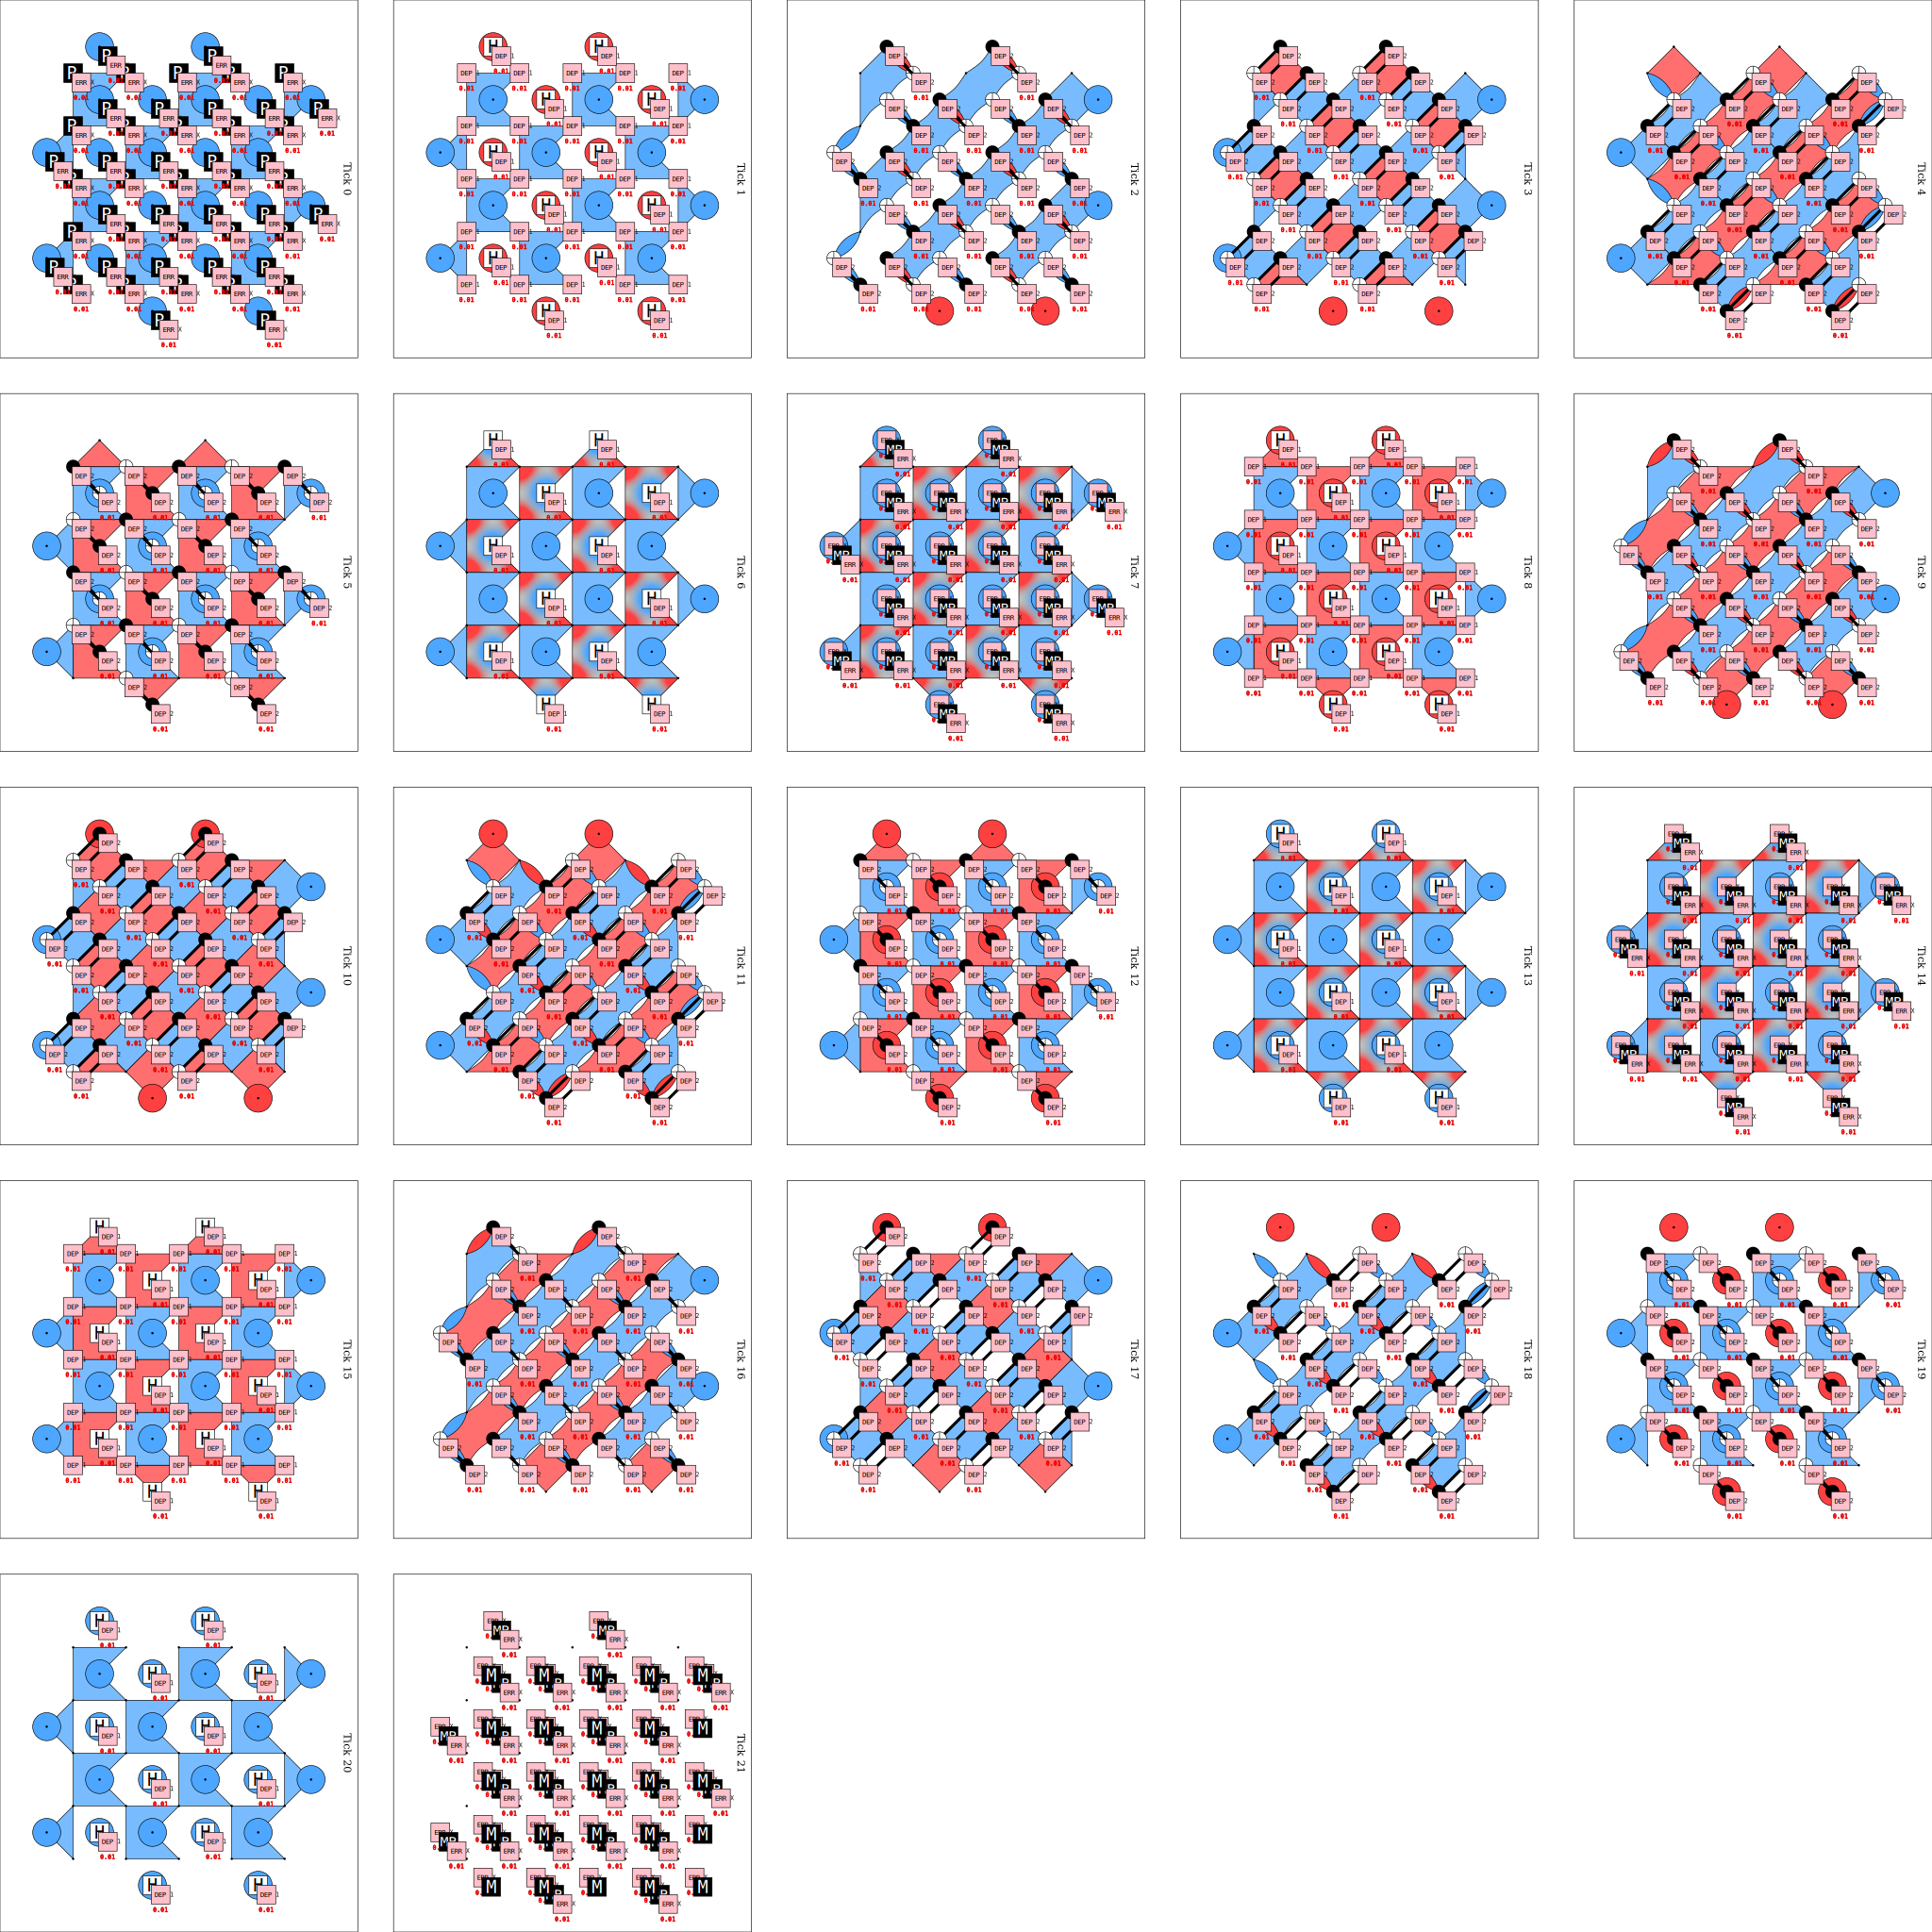

In [20]:
CIRC.diagram('detslice-with-ops-svg')


### Custom static figure — this shot on the lattice (slide-ready)

Cleaner than `detslice` for a *single failure*: grey dots are the qubit lattice, **orange circles**
are the detectors that fired **in that round**, and the **diamonds** are the injected physical
errors (**X = red, Y = green, Z = blue**) drawn on the qubits they hit. Reading the panels
left → right shows the error's footprint appearing across rounds. This is the one to drop into a
slide.

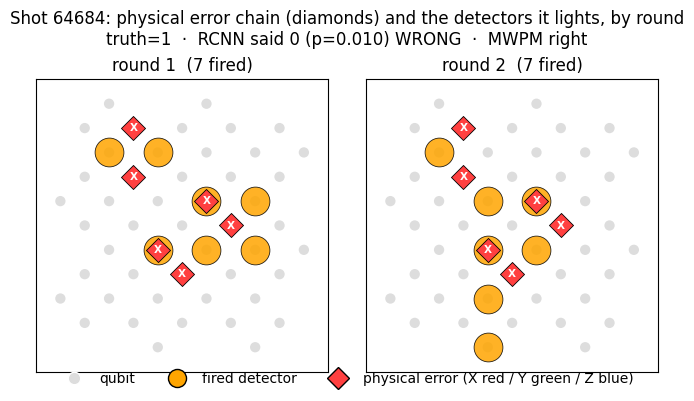

In [21]:
QC = CIRC.get_final_qubit_coordinates()
qx = np.array([v[0] for v in QC.values()]); qy = np.array([v[1] for v in QC.values()])

det_df = fired_detectors(SHOT)
_, _, chain_df = physical_error_chain(SHOT)
err_xy = list(chain_df['coords']); err_p = list(chain_df['pauli'])
pcol = {'X': '#FF4040', 'Y': '#2CA02C', 'Z': '#4DA6FF'}

rounds_present = sorted(det_df['round'].unique())
fig, axes = plt.subplots(1, len(rounds_present), figsize=(3.3*len(rounds_present), 3.7),
                         constrained_layout=True, squeeze=False)
for ax, t in zip(axes[0], rounds_present):
    ax.scatter(qx, qy, s=55, color='#dddddd', edgecolors='none', zorder=1)   # lattice
    d = det_df[det_df['round'] == t]
    ax.scatter(d['x'], d['y'], s=430, facecolor='#FFA500', edgecolors='k',
               linewidths=0.6, alpha=0.85, zorder=2)                          # fired detectors
    for (xx, yy), pp in zip(err_xy, err_p):                                    # physical errors
        ax.scatter(xx, yy, marker='D', s=150, facecolor=pcol.get(pp, 'k'),
                   edgecolors='k', linewidths=0.6, zorder=3)
        ax.text(xx, yy, pp, ha='center', va='center', fontsize=7.5,
                color='white', fontweight='bold', zorder=4)
    ax.set_title(f"round {t}  ({len(d)} fired)")
    ax.set_aspect('equal'); ax.set_xlim(-1, 11); ax.set_ylim(11, -1)
    ax.set_xticks([]); ax.set_yticks([])

from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#dddddd', markersize=9, label='qubit'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markeredgecolor='k',
           markersize=13, label='fired detector'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#FF4040', markeredgecolor='k',
           markersize=11, label='physical error (X red / Y green / Z blue)')]
fig.legend(handles=handles, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.06), frameon=False)
fig.suptitle(f"Shot {SHOT}: physical error chain (diamonds) and the detectors it lights, by round\n"
             f"truth={truth[SHOT]}  ·  RCNN said {rcnn_pred[SHOT]} (p={rcnn_prob[SHOT]:.3f}) WRONG  ·  MWPM right")
plt.show()


## 4 · Browse — Crumble links for the top-K most-confidently-wrong shots

A quick clickable list so you can flip through several failure cases without re-running the deep
dive each time.

In [22]:
K = 8
links = []
for _, r_ in rows.head(K).iterrows():
    s = int(r_['shot'])
    _, ex, _ = physical_error_chain(s)
    u = CIRC.to_crumble_url(mark={1: ex})
    links.append(f"- shot **{s}**  (truth={r_['truth']}, rcnn_prob={r_['rcnn_prob']}, "
                 f"{int(r_['n_det_fired'])} dets) — [open in Crumble]({u})")
display(Markdown("\n".join(links)))


- shot **64684**  (truth=1.0, rcnn_prob=0.01, 14 dets) — [open in Crumble](https://algassert.com/crumble#circuit=Q(1,1)1;Q(2,0)2;Q(3,1)3;Q(5,1)5;Q(6,0)6;Q(7,1)7;Q(9,1)9;Q(1,3)12;Q(2,2)13;Q(3,3)14;Q(4,2)15;Q(5,3)16;Q(6,2)17;Q(7,3)18;Q(8,2)19;Q(9,3)20;Q(10,2)21;Q(0,4)22;Q(1,5)23;Q(2,4)24;Q(3,5)25;Q(4,4)26;Q(5,5)27;Q(6,4)28;Q(7,5)29;Q(8,4)30;Q(9,5)31;Q(1,7)34;Q(2,6)35;Q(3,7)36;Q(4,6)37;Q(5,7)38;Q(6,6)39;Q(7,7)40;Q(8,6)41;Q(9,7)42;Q(10,6)43;Q(0,8)44;Q(1,9)45;Q(2,8)46;Q(3,9)47;Q(4,8)48;Q(5,9)49;Q(6,8)50;Q(7,9)51;Q(8,8)52;Q(9,9)53;Q(4,10)59;Q(8,10)63;R_1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;X_ERROR(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;R_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;TICK;DEPOLARIZE1(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;CX_2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;DEPOLARIZE2(0.01)2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;TICK;CX_2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;TICK;MARKX(1)3;TICK;DEPOLARIZE2(0.01)2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;TICK;CX_24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;MARKX(1)29;TICK;DEPOLARIZE2(0.01)24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;CX_24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;DEPOLARIZE2(0.01)24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;TICK;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;MR_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;TICK;MARKX(1)28;MARKX(1)37;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;DT(0,4,0)rec[-17];DT(0,8,0)rec[-7];DT(2,2,0)rec[-22];DT(2,6,0)rec[-12];DT(4,4,0)rec[-15];DT(4,8,0)rec[-5];DT(6,2,0)rec[-20];DT(6,6,0)rec[-10];DT(8,4,0)rec[-13];DT(8,8,0)rec[-3];DT(10,2,0)rec[-18];DT(10,6,0)rec[-8];REPEAT_2_{;TICK;DEPOLARIZE1(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;CX_2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;DEPOLARIZE2(0.01)2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;TICK;CX_2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;DEPOLARIZE2(0.01)2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;TICK;CX_24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;DEPOLARIZE2(0.01)24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;CX_24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;DEPOLARIZE2(0.01)24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;TICK;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;MR_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;SHIFT_COORDS(0,0,1);DT(2,0,0)rec[-24]_rec[-48];DT(6,0,0)rec[-23]_rec[-47];DT(2,2,0)rec[-22]_rec[-46];DT(4,2,0)rec[-21]_rec[-45];DT(6,2,0)rec[-20]_rec[-44];DT(8,2,0)rec[-19]_rec[-43];DT(10,2,0)rec[-18]_rec[-42];DT(0,4,0)rec[-17]_rec[-41];DT(2,4,0)rec[-16]_rec[-40];DT(4,4,0)rec[-15]_rec[-39];DT(6,4,0)rec[-14]_rec[-38];DT(8,4,0)rec[-13]_rec[-37];DT(2,6,0)rec[-12]_rec[-36];DT(4,6,0)rec[-11]_rec[-35];DT(6,6,0)rec[-10]_rec[-34];DT(8,6,0)rec[-9]_rec[-33];DT(10,6,0)rec[-8]_rec[-32];DT(0,8,0)rec[-7]_rec[-31];DT(2,8,0)rec[-6]_rec[-30];DT(4,8,0)rec[-5]_rec[-29];DT(6,8,0)rec[-4]_rec[-28];DT(8,8,0)rec[-3]_rec[-27];DT(4,10,0)rec[-2]_rec[-26];DT(8,10,0)rec[-1]_rec[-25];};X_ERROR(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;M_1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;DT(0,4,1)rec[-15]_rec[-20]_rec[-42];DT(0,8,1)rec[-5]_rec[-10]_rec[-32];DT(2,2,1)rec[-19]_rec[-20]_rec[-24]_rec[-25]_rec[-47];DT(2,6,1)rec[-9]_rec[-10]_rec[-14]_rec[-15]_rec[-37];DT(4,4,1)rec[-13]_rec[-14]_rec[-18]_rec[-19]_rec[-40];DT(4,8,1)rec[-3]_rec[-4]_rec[-8]_rec[-9]_rec[-30];DT(6,2,1)rec[-17]_rec[-18]_rec[-22]_rec[-23]_rec[-45];DT(6,6,1)rec[-7]_rec[-8]_rec[-12]_rec[-13]_rec[-35];DT(8,4,1)rec[-11]_rec[-12]_rec[-16]_rec[-17]_rec[-38];DT(8,8,1)rec[-1]_rec[-2]_rec[-6]_rec[-7]_rec[-28];DT(10,2,1)rec[-16]_rec[-21]_rec[-43];DT(10,6,1)rec[-6]_rec[-11]_rec[-33];OI(0)rec[-21]_rec[-22]_rec[-23]_rec[-24]_rec[-25]_)
- shot **49639**  (truth=0.0, rcnn_prob=0.989, 11 dets) — [open in Crumble](https://algassert.com/crumble#circuit=Q(1,1)1;Q(2,0)2;Q(3,1)3;Q(5,1)5;Q(6,0)6;Q(7,1)7;Q(9,1)9;Q(1,3)12;Q(2,2)13;Q(3,3)14;Q(4,2)15;Q(5,3)16;Q(6,2)17;Q(7,3)18;Q(8,2)19;Q(9,3)20;Q(10,2)21;Q(0,4)22;Q(1,5)23;Q(2,4)24;Q(3,5)25;Q(4,4)26;Q(5,5)27;Q(6,4)28;Q(7,5)29;Q(8,4)30;Q(9,5)31;Q(1,7)34;Q(2,6)35;Q(3,7)36;Q(4,6)37;Q(5,7)38;Q(6,6)39;Q(7,7)40;Q(8,6)41;Q(9,7)42;Q(10,6)43;Q(0,8)44;Q(1,9)45;Q(2,8)46;Q(3,9)47;Q(4,8)48;Q(5,9)49;Q(6,8)50;Q(7,9)51;Q(8,8)52;Q(9,9)53;Q(4,10)59;Q(8,10)63;R_1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;TICK;MARKX(1)12;TICK;X_ERROR(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;R_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;TICK;DEPOLARIZE1(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;CX_2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;DEPOLARIZE2(0.01)2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;TICK;CX_2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;DEPOLARIZE2(0.01)2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;TICK;CX_24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;DEPOLARIZE2(0.01)24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;CX_24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;DEPOLARIZE2(0.01)24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;TICK;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;MR_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;TICK;MARKX(1)21;MARKX(1)24;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;DT(0,4,0)rec[-17];DT(0,8,0)rec[-7];DT(2,2,0)rec[-22];DT(2,6,0)rec[-12];DT(4,4,0)rec[-15];DT(4,8,0)rec[-5];DT(6,2,0)rec[-20];DT(6,6,0)rec[-10];DT(8,4,0)rec[-13];DT(8,8,0)rec[-3];DT(10,2,0)rec[-18];DT(10,6,0)rec[-8];REPEAT_2_{;TICK;DEPOLARIZE1(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;CX_2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;DEPOLARIZE2(0.01)2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;TICK;CX_2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;DEPOLARIZE2(0.01)2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;TICK;CX_24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;DEPOLARIZE2(0.01)24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;CX_24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;DEPOLARIZE2(0.01)24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;TICK;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;MR_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;SHIFT_COORDS(0,0,1);DT(2,0,0)rec[-24]_rec[-48];DT(6,0,0)rec[-23]_rec[-47];DT(2,2,0)rec[-22]_rec[-46];DT(4,2,0)rec[-21]_rec[-45];DT(6,2,0)rec[-20]_rec[-44];DT(8,2,0)rec[-19]_rec[-43];DT(10,2,0)rec[-18]_rec[-42];DT(0,4,0)rec[-17]_rec[-41];DT(2,4,0)rec[-16]_rec[-40];DT(4,4,0)rec[-15]_rec[-39];DT(6,4,0)rec[-14]_rec[-38];DT(8,4,0)rec[-13]_rec[-37];DT(2,6,0)rec[-12]_rec[-36];DT(4,6,0)rec[-11]_rec[-35];DT(6,6,0)rec[-10]_rec[-34];DT(8,6,0)rec[-9]_rec[-33];DT(10,6,0)rec[-8]_rec[-32];DT(0,8,0)rec[-7]_rec[-31];DT(2,8,0)rec[-6]_rec[-30];DT(4,8,0)rec[-5]_rec[-29];DT(6,8,0)rec[-4]_rec[-28];DT(8,8,0)rec[-3]_rec[-27];DT(4,10,0)rec[-2]_rec[-26];DT(8,10,0)rec[-1]_rec[-25];};X_ERROR(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;M_1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;DT(0,4,1)rec[-15]_rec[-20]_rec[-42];DT(0,8,1)rec[-5]_rec[-10]_rec[-32];DT(2,2,1)rec[-19]_rec[-20]_rec[-24]_rec[-25]_rec[-47];DT(2,6,1)rec[-9]_rec[-10]_rec[-14]_rec[-15]_rec[-37];DT(4,4,1)rec[-13]_rec[-14]_rec[-18]_rec[-19]_rec[-40];DT(4,8,1)rec[-3]_rec[-4]_rec[-8]_rec[-9]_rec[-30];DT(6,2,1)rec[-17]_rec[-18]_rec[-22]_rec[-23]_rec[-45];DT(6,6,1)rec[-7]_rec[-8]_rec[-12]_rec[-13]_rec[-35];DT(8,4,1)rec[-11]_rec[-12]_rec[-16]_rec[-17]_rec[-38];DT(8,8,1)rec[-1]_rec[-2]_rec[-6]_rec[-7]_rec[-28];DT(10,2,1)rec[-16]_rec[-21]_rec[-43];DT(10,6,1)rec[-6]_rec[-11]_rec[-33];OI(0)rec[-21]_rec[-22]_rec[-23]_rec[-24]_rec[-25]_)
- shot **111990**  (truth=1.0, rcnn_prob=0.018, 15 dets) — [open in Crumble](https://algassert.com/crumble#circuit=Q(1,1)1;Q(2,0)2;Q(3,1)3;Q(5,1)5;Q(6,0)6;Q(7,1)7;Q(9,1)9;Q(1,3)12;Q(2,2)13;Q(3,3)14;Q(4,2)15;Q(5,3)16;Q(6,2)17;Q(7,3)18;Q(8,2)19;Q(9,3)20;Q(10,2)21;Q(0,4)22;Q(1,5)23;Q(2,4)24;Q(3,5)25;Q(4,4)26;Q(5,5)27;Q(6,4)28;Q(7,5)29;Q(8,4)30;Q(9,5)31;Q(1,7)34;Q(2,6)35;Q(3,7)36;Q(4,6)37;Q(5,7)38;Q(6,6)39;Q(7,7)40;Q(8,6)41;Q(9,7)42;Q(10,6)43;Q(0,8)44;Q(1,9)45;Q(2,8)46;Q(3,9)47;Q(4,8)48;Q(5,9)49;Q(6,8)50;Q(7,9)51;Q(8,8)52;Q(9,9)53;Q(4,10)59;Q(8,10)63;R_1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;X_ERROR(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;R_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;TICK;MARKX(1)22;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;TICK;DEPOLARIZE1(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;CX_2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;DEPOLARIZE2(0.01)2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;TICK;CX_2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;DEPOLARIZE2(0.01)2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;TICK;CX_24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;MARKX(1)38;TICK;DEPOLARIZE2(0.01)24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;CX_24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;DEPOLARIZE2(0.01)24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;TICK;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;MR_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;TICK;MARKX(1)41;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;DT(0,4,0)rec[-17];DT(0,8,0)rec[-7];DT(2,2,0)rec[-22];DT(2,6,0)rec[-12];DT(4,4,0)rec[-15];DT(4,8,0)rec[-5];DT(6,2,0)rec[-20];DT(6,6,0)rec[-10];DT(8,4,0)rec[-13];DT(8,8,0)rec[-3];DT(10,2,0)rec[-18];DT(10,6,0)rec[-8];REPEAT_2_{;TICK;DEPOLARIZE1(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;CX_2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;DEPOLARIZE2(0.01)2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;TICK;CX_2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;DEPOLARIZE2(0.01)2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;TICK;CX_24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;DEPOLARIZE2(0.01)24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;CX_24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;DEPOLARIZE2(0.01)24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;TICK;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;MR_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;SHIFT_COORDS(0,0,1);DT(2,0,0)rec[-24]_rec[-48];DT(6,0,0)rec[-23]_rec[-47];DT(2,2,0)rec[-22]_rec[-46];DT(4,2,0)rec[-21]_rec[-45];DT(6,2,0)rec[-20]_rec[-44];DT(8,2,0)rec[-19]_rec[-43];DT(10,2,0)rec[-18]_rec[-42];DT(0,4,0)rec[-17]_rec[-41];DT(2,4,0)rec[-16]_rec[-40];DT(4,4,0)rec[-15]_rec[-39];DT(6,4,0)rec[-14]_rec[-38];DT(8,4,0)rec[-13]_rec[-37];DT(2,6,0)rec[-12]_rec[-36];DT(4,6,0)rec[-11]_rec[-35];DT(6,6,0)rec[-10]_rec[-34];DT(8,6,0)rec[-9]_rec[-33];DT(10,6,0)rec[-8]_rec[-32];DT(0,8,0)rec[-7]_rec[-31];DT(2,8,0)rec[-6]_rec[-30];DT(4,8,0)rec[-5]_rec[-29];DT(6,8,0)rec[-4]_rec[-28];DT(8,8,0)rec[-3]_rec[-27];DT(4,10,0)rec[-2]_rec[-26];DT(8,10,0)rec[-1]_rec[-25];};X_ERROR(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;M_1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;DT(0,4,1)rec[-15]_rec[-20]_rec[-42];DT(0,8,1)rec[-5]_rec[-10]_rec[-32];DT(2,2,1)rec[-19]_rec[-20]_rec[-24]_rec[-25]_rec[-47];DT(2,6,1)rec[-9]_rec[-10]_rec[-14]_rec[-15]_rec[-37];DT(4,4,1)rec[-13]_rec[-14]_rec[-18]_rec[-19]_rec[-40];DT(4,8,1)rec[-3]_rec[-4]_rec[-8]_rec[-9]_rec[-30];DT(6,2,1)rec[-17]_rec[-18]_rec[-22]_rec[-23]_rec[-45];DT(6,6,1)rec[-7]_rec[-8]_rec[-12]_rec[-13]_rec[-35];DT(8,4,1)rec[-11]_rec[-12]_rec[-16]_rec[-17]_rec[-38];DT(8,8,1)rec[-1]_rec[-2]_rec[-6]_rec[-7]_rec[-28];DT(10,2,1)rec[-16]_rec[-21]_rec[-43];DT(10,6,1)rec[-6]_rec[-11]_rec[-33];OI(0)rec[-21]_rec[-22]_rec[-23]_rec[-24]_rec[-25]_)
- shot **47012**  (truth=0.0, rcnn_prob=0.981, 9 dets) — [open in Crumble](https://algassert.com/crumble#circuit=Q(1,1)1;Q(2,0)2;Q(3,1)3;Q(5,1)5;Q(6,0)6;Q(7,1)7;Q(9,1)9;Q(1,3)12;Q(2,2)13;Q(3,3)14;Q(4,2)15;Q(5,3)16;Q(6,2)17;Q(7,3)18;Q(8,2)19;Q(9,3)20;Q(10,2)21;Q(0,4)22;Q(1,5)23;Q(2,4)24;Q(3,5)25;Q(4,4)26;Q(5,5)27;Q(6,4)28;Q(7,5)29;Q(8,4)30;Q(9,5)31;Q(1,7)34;Q(2,6)35;Q(3,7)36;Q(4,6)37;Q(5,7)38;Q(6,6)39;Q(7,7)40;Q(8,6)41;Q(9,7)42;Q(10,6)43;Q(0,8)44;Q(1,9)45;Q(2,8)46;Q(3,9)47;Q(4,8)48;Q(5,9)49;Q(6,8)50;Q(7,9)51;Q(8,8)52;Q(9,9)53;Q(4,10)59;Q(8,10)63;R_1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;TICK;MARKX(1)14;MARKX(1)25;TICK;X_ERROR(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;R_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;TICK;DEPOLARIZE1(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;CX_2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;DEPOLARIZE2(0.01)2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;TICK;CX_2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;DEPOLARIZE2(0.01)2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;TICK;CX_24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;DEPOLARIZE2(0.01)24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;CX_24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;DEPOLARIZE2(0.01)24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;TICK;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;MR_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;DT(0,4,0)rec[-17];DT(0,8,0)rec[-7];DT(2,2,0)rec[-22];DT(2,6,0)rec[-12];DT(4,4,0)rec[-15];DT(4,8,0)rec[-5];DT(6,2,0)rec[-20];DT(6,6,0)rec[-10];DT(8,4,0)rec[-13];DT(8,8,0)rec[-3];DT(10,2,0)rec[-18];DT(10,6,0)rec[-8];REPEAT_2_{;TICK;DEPOLARIZE1(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;CX_2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;DEPOLARIZE2(0.01)2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;TICK;CX_2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;DEPOLARIZE2(0.01)2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;TICK;CX_24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;DEPOLARIZE2(0.01)24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;CX_24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;DEPOLARIZE2(0.01)24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;TICK;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;MR_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;SHIFT_COORDS(0,0,1);DT(2,0,0)rec[-24]_rec[-48];DT(6,0,0)rec[-23]_rec[-47];DT(2,2,0)rec[-22]_rec[-46];DT(4,2,0)rec[-21]_rec[-45];DT(6,2,0)rec[-20]_rec[-44];DT(8,2,0)rec[-19]_rec[-43];DT(10,2,0)rec[-18]_rec[-42];DT(0,4,0)rec[-17]_rec[-41];DT(2,4,0)rec[-16]_rec[-40];DT(4,4,0)rec[-15]_rec[-39];DT(6,4,0)rec[-14]_rec[-38];DT(8,4,0)rec[-13]_rec[-37];DT(2,6,0)rec[-12]_rec[-36];DT(4,6,0)rec[-11]_rec[-35];DT(6,6,0)rec[-10]_rec[-34];DT(8,6,0)rec[-9]_rec[-33];DT(10,6,0)rec[-8]_rec[-32];DT(0,8,0)rec[-7]_rec[-31];DT(2,8,0)rec[-6]_rec[-30];DT(4,8,0)rec[-5]_rec[-29];DT(6,8,0)rec[-4]_rec[-28];DT(8,8,0)rec[-3]_rec[-27];DT(4,10,0)rec[-2]_rec[-26];DT(8,10,0)rec[-1]_rec[-25];};X_ERROR(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;M_1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;DT(0,4,1)rec[-15]_rec[-20]_rec[-42];DT(0,8,1)rec[-5]_rec[-10]_rec[-32];DT(2,2,1)rec[-19]_rec[-20]_rec[-24]_rec[-25]_rec[-47];DT(2,6,1)rec[-9]_rec[-10]_rec[-14]_rec[-15]_rec[-37];DT(4,4,1)rec[-13]_rec[-14]_rec[-18]_rec[-19]_rec[-40];DT(4,8,1)rec[-3]_rec[-4]_rec[-8]_rec[-9]_rec[-30];DT(6,2,1)rec[-17]_rec[-18]_rec[-22]_rec[-23]_rec[-45];DT(6,6,1)rec[-7]_rec[-8]_rec[-12]_rec[-13]_rec[-35];DT(8,4,1)rec[-11]_rec[-12]_rec[-16]_rec[-17]_rec[-38];DT(8,8,1)rec[-1]_rec[-2]_rec[-6]_rec[-7]_rec[-28];DT(10,2,1)rec[-16]_rec[-21]_rec[-43];DT(10,6,1)rec[-6]_rec[-11]_rec[-33];OI(0)rec[-21]_rec[-22]_rec[-23]_rec[-24]_rec[-25]_)
- shot **12756**  (truth=0.0, rcnn_prob=0.979, 17 dets) — [open in Crumble](https://algassert.com/crumble#circuit=Q(1,1)1;Q(2,0)2;Q(3,1)3;Q(5,1)5;Q(6,0)6;Q(7,1)7;Q(9,1)9;Q(1,3)12;Q(2,2)13;Q(3,3)14;Q(4,2)15;Q(5,3)16;Q(6,2)17;Q(7,3)18;Q(8,2)19;Q(9,3)20;Q(10,2)21;Q(0,4)22;Q(1,5)23;Q(2,4)24;Q(3,5)25;Q(4,4)26;Q(5,5)27;Q(6,4)28;Q(7,5)29;Q(8,4)30;Q(9,5)31;Q(1,7)34;Q(2,6)35;Q(3,7)36;Q(4,6)37;Q(5,7)38;Q(6,6)39;Q(7,7)40;Q(8,6)41;Q(9,7)42;Q(10,6)43;Q(0,8)44;Q(1,9)45;Q(2,8)46;Q(3,9)47;Q(4,8)48;Q(5,9)49;Q(6,8)50;Q(7,9)51;Q(8,8)52;Q(9,9)53;Q(4,10)59;Q(8,10)63;R_1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;TICK;MARKX(1)23;MARKX(1)16;TICK;X_ERROR(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;R_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;TICK;DEPOLARIZE1(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;CX_2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;DEPOLARIZE2(0.01)2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;TICK;CX_2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;DEPOLARIZE2(0.01)2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;TICK;CX_24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;MARKX(1)29;TICK;DEPOLARIZE2(0.01)24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;CX_24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;DEPOLARIZE2(0.01)24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;TICK;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;MR_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;TICK;MARKX(1)43;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;DT(0,4,0)rec[-17];DT(0,8,0)rec[-7];DT(2,2,0)rec[-22];DT(2,6,0)rec[-12];DT(4,4,0)rec[-15];DT(4,8,0)rec[-5];DT(6,2,0)rec[-20];DT(6,6,0)rec[-10];DT(8,4,0)rec[-13];DT(8,8,0)rec[-3];DT(10,2,0)rec[-18];DT(10,6,0)rec[-8];REPEAT_2_{;TICK;DEPOLARIZE1(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;CX_2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;DEPOLARIZE2(0.01)2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;TICK;CX_2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;DEPOLARIZE2(0.01)2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;TICK;CX_24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;DEPOLARIZE2(0.01)24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;CX_24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;DEPOLARIZE2(0.01)24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;TICK;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;MR_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;SHIFT_COORDS(0,0,1);DT(2,0,0)rec[-24]_rec[-48];DT(6,0,0)rec[-23]_rec[-47];DT(2,2,0)rec[-22]_rec[-46];DT(4,2,0)rec[-21]_rec[-45];DT(6,2,0)rec[-20]_rec[-44];DT(8,2,0)rec[-19]_rec[-43];DT(10,2,0)rec[-18]_rec[-42];DT(0,4,0)rec[-17]_rec[-41];DT(2,4,0)rec[-16]_rec[-40];DT(4,4,0)rec[-15]_rec[-39];DT(6,4,0)rec[-14]_rec[-38];DT(8,4,0)rec[-13]_rec[-37];DT(2,6,0)rec[-12]_rec[-36];DT(4,6,0)rec[-11]_rec[-35];DT(6,6,0)rec[-10]_rec[-34];DT(8,6,0)rec[-9]_rec[-33];DT(10,6,0)rec[-8]_rec[-32];DT(0,8,0)rec[-7]_rec[-31];DT(2,8,0)rec[-6]_rec[-30];DT(4,8,0)rec[-5]_rec[-29];DT(6,8,0)rec[-4]_rec[-28];DT(8,8,0)rec[-3]_rec[-27];DT(4,10,0)rec[-2]_rec[-26];DT(8,10,0)rec[-1]_rec[-25];};X_ERROR(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;M_1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;DT(0,4,1)rec[-15]_rec[-20]_rec[-42];DT(0,8,1)rec[-5]_rec[-10]_rec[-32];DT(2,2,1)rec[-19]_rec[-20]_rec[-24]_rec[-25]_rec[-47];DT(2,6,1)rec[-9]_rec[-10]_rec[-14]_rec[-15]_rec[-37];DT(4,4,1)rec[-13]_rec[-14]_rec[-18]_rec[-19]_rec[-40];DT(4,8,1)rec[-3]_rec[-4]_rec[-8]_rec[-9]_rec[-30];DT(6,2,1)rec[-17]_rec[-18]_rec[-22]_rec[-23]_rec[-45];DT(6,6,1)rec[-7]_rec[-8]_rec[-12]_rec[-13]_rec[-35];DT(8,4,1)rec[-11]_rec[-12]_rec[-16]_rec[-17]_rec[-38];DT(8,8,1)rec[-1]_rec[-2]_rec[-6]_rec[-7]_rec[-28];DT(10,2,1)rec[-16]_rec[-21]_rec[-43];DT(10,6,1)rec[-6]_rec[-11]_rec[-33];OI(0)rec[-21]_rec[-22]_rec[-23]_rec[-24]_rec[-25]_)
- shot **165315**  (truth=1.0, rcnn_prob=0.021, 14 dets) — [open in Crumble](https://algassert.com/crumble#circuit=Q(1,1)1;Q(2,0)2;Q(3,1)3;Q(5,1)5;Q(6,0)6;Q(7,1)7;Q(9,1)9;Q(1,3)12;Q(2,2)13;Q(3,3)14;Q(4,2)15;Q(5,3)16;Q(6,2)17;Q(7,3)18;Q(8,2)19;Q(9,3)20;Q(10,2)21;Q(0,4)22;Q(1,5)23;Q(2,4)24;Q(3,5)25;Q(4,4)26;Q(5,5)27;Q(6,4)28;Q(7,5)29;Q(8,4)30;Q(9,5)31;Q(1,7)34;Q(2,6)35;Q(3,7)36;Q(4,6)37;Q(5,7)38;Q(6,6)39;Q(7,7)40;Q(8,6)41;Q(9,7)42;Q(10,6)43;Q(0,8)44;Q(1,9)45;Q(2,8)46;Q(3,9)47;Q(4,8)48;Q(5,9)49;Q(6,8)50;Q(7,9)51;Q(8,8)52;Q(9,9)53;Q(4,10)59;Q(8,10)63;R_1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;TICK;MARKX(1)9;TICK;X_ERROR(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;R_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;TICK;DEPOLARIZE1(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;CX_2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;DEPOLARIZE2(0.01)2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;TICK;CX_2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;DEPOLARIZE2(0.01)2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;TICK;CX_24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;MARKX(1)38;TICK;DEPOLARIZE2(0.01)24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;CX_24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;DEPOLARIZE2(0.01)24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;TICK;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;MR_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;TICK;MARKX(1)21;MARKX(1)37;MARKX(1)50;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;DT(0,4,0)rec[-17];DT(0,8,0)rec[-7];DT(2,2,0)rec[-22];DT(2,6,0)rec[-12];DT(4,4,0)rec[-15];DT(4,8,0)rec[-5];DT(6,2,0)rec[-20];DT(6,6,0)rec[-10];DT(8,4,0)rec[-13];DT(8,8,0)rec[-3];DT(10,2,0)rec[-18];DT(10,6,0)rec[-8];REPEAT_2_{;TICK;DEPOLARIZE1(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;CX_2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;DEPOLARIZE2(0.01)2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;TICK;CX_2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;DEPOLARIZE2(0.01)2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;TICK;CX_24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;DEPOLARIZE2(0.01)24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;CX_24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;DEPOLARIZE2(0.01)24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;TICK;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;MR_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;SHIFT_COORDS(0,0,1);DT(2,0,0)rec[-24]_rec[-48];DT(6,0,0)rec[-23]_rec[-47];DT(2,2,0)rec[-22]_rec[-46];DT(4,2,0)rec[-21]_rec[-45];DT(6,2,0)rec[-20]_rec[-44];DT(8,2,0)rec[-19]_rec[-43];DT(10,2,0)rec[-18]_rec[-42];DT(0,4,0)rec[-17]_rec[-41];DT(2,4,0)rec[-16]_rec[-40];DT(4,4,0)rec[-15]_rec[-39];DT(6,4,0)rec[-14]_rec[-38];DT(8,4,0)rec[-13]_rec[-37];DT(2,6,0)rec[-12]_rec[-36];DT(4,6,0)rec[-11]_rec[-35];DT(6,6,0)rec[-10]_rec[-34];DT(8,6,0)rec[-9]_rec[-33];DT(10,6,0)rec[-8]_rec[-32];DT(0,8,0)rec[-7]_rec[-31];DT(2,8,0)rec[-6]_rec[-30];DT(4,8,0)rec[-5]_rec[-29];DT(6,8,0)rec[-4]_rec[-28];DT(8,8,0)rec[-3]_rec[-27];DT(4,10,0)rec[-2]_rec[-26];DT(8,10,0)rec[-1]_rec[-25];};X_ERROR(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;M_1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;DT(0,4,1)rec[-15]_rec[-20]_rec[-42];DT(0,8,1)rec[-5]_rec[-10]_rec[-32];DT(2,2,1)rec[-19]_rec[-20]_rec[-24]_rec[-25]_rec[-47];DT(2,6,1)rec[-9]_rec[-10]_rec[-14]_rec[-15]_rec[-37];DT(4,4,1)rec[-13]_rec[-14]_rec[-18]_rec[-19]_rec[-40];DT(4,8,1)rec[-3]_rec[-4]_rec[-8]_rec[-9]_rec[-30];DT(6,2,1)rec[-17]_rec[-18]_rec[-22]_rec[-23]_rec[-45];DT(6,6,1)rec[-7]_rec[-8]_rec[-12]_rec[-13]_rec[-35];DT(8,4,1)rec[-11]_rec[-12]_rec[-16]_rec[-17]_rec[-38];DT(8,8,1)rec[-1]_rec[-2]_rec[-6]_rec[-7]_rec[-28];DT(10,2,1)rec[-16]_rec[-21]_rec[-43];DT(10,6,1)rec[-6]_rec[-11]_rec[-33];OI(0)rec[-21]_rec[-22]_rec[-23]_rec[-24]_rec[-25]_)
- shot **14091**  (truth=0.0, rcnn_prob=0.979, 10 dets) — [open in Crumble](https://algassert.com/crumble#circuit=Q(1,1)1;Q(2,0)2;Q(3,1)3;Q(5,1)5;Q(6,0)6;Q(7,1)7;Q(9,1)9;Q(1,3)12;Q(2,2)13;Q(3,3)14;Q(4,2)15;Q(5,3)16;Q(6,2)17;Q(7,3)18;Q(8,2)19;Q(9,3)20;Q(10,2)21;Q(0,4)22;Q(1,5)23;Q(2,4)24;Q(3,5)25;Q(4,4)26;Q(5,5)27;Q(6,4)28;Q(7,5)29;Q(8,4)30;Q(9,5)31;Q(1,7)34;Q(2,6)35;Q(3,7)36;Q(4,6)37;Q(5,7)38;Q(6,6)39;Q(7,7)40;Q(8,6)41;Q(9,7)42;Q(10,6)43;Q(0,8)44;Q(1,9)45;Q(2,8)46;Q(3,9)47;Q(4,8)48;Q(5,9)49;Q(6,8)50;Q(7,9)51;Q(8,8)52;Q(9,9)53;Q(4,10)59;Q(8,10)63;R_1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;TICK;MARKX(1)23;TICK;X_ERROR(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;R_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;TICK;DEPOLARIZE1(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;CX_2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;DEPOLARIZE2(0.01)2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;TICK;CX_2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;DEPOLARIZE2(0.01)2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;TICK;CX_24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;DEPOLARIZE2(0.01)24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;CX_24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;DEPOLARIZE2(0.01)24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;TICK;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;MR_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;TICK;MARKX(1)17;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;DT(0,4,0)rec[-17];DT(0,8,0)rec[-7];DT(2,2,0)rec[-22];DT(2,6,0)rec[-12];DT(4,4,0)rec[-15];DT(4,8,0)rec[-5];DT(6,2,0)rec[-20];DT(6,6,0)rec[-10];DT(8,4,0)rec[-13];DT(8,8,0)rec[-3];DT(10,2,0)rec[-18];DT(10,6,0)rec[-8];REPEAT_2_{;TICK;DEPOLARIZE1(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;CX_2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;DEPOLARIZE2(0.01)2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;TICK;CX_2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;DEPOLARIZE2(0.01)2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;TICK;CX_24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;DEPOLARIZE2(0.01)24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;CX_24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;DEPOLARIZE2(0.01)24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;TICK;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;MR_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;SHIFT_COORDS(0,0,1);DT(2,0,0)rec[-24]_rec[-48];DT(6,0,0)rec[-23]_rec[-47];DT(2,2,0)rec[-22]_rec[-46];DT(4,2,0)rec[-21]_rec[-45];DT(6,2,0)rec[-20]_rec[-44];DT(8,2,0)rec[-19]_rec[-43];DT(10,2,0)rec[-18]_rec[-42];DT(0,4,0)rec[-17]_rec[-41];DT(2,4,0)rec[-16]_rec[-40];DT(4,4,0)rec[-15]_rec[-39];DT(6,4,0)rec[-14]_rec[-38];DT(8,4,0)rec[-13]_rec[-37];DT(2,6,0)rec[-12]_rec[-36];DT(4,6,0)rec[-11]_rec[-35];DT(6,6,0)rec[-10]_rec[-34];DT(8,6,0)rec[-9]_rec[-33];DT(10,6,0)rec[-8]_rec[-32];DT(0,8,0)rec[-7]_rec[-31];DT(2,8,0)rec[-6]_rec[-30];DT(4,8,0)rec[-5]_rec[-29];DT(6,8,0)rec[-4]_rec[-28];DT(8,8,0)rec[-3]_rec[-27];DT(4,10,0)rec[-2]_rec[-26];DT(8,10,0)rec[-1]_rec[-25];};X_ERROR(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;M_1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;DT(0,4,1)rec[-15]_rec[-20]_rec[-42];DT(0,8,1)rec[-5]_rec[-10]_rec[-32];DT(2,2,1)rec[-19]_rec[-20]_rec[-24]_rec[-25]_rec[-47];DT(2,6,1)rec[-9]_rec[-10]_rec[-14]_rec[-15]_rec[-37];DT(4,4,1)rec[-13]_rec[-14]_rec[-18]_rec[-19]_rec[-40];DT(4,8,1)rec[-3]_rec[-4]_rec[-8]_rec[-9]_rec[-30];DT(6,2,1)rec[-17]_rec[-18]_rec[-22]_rec[-23]_rec[-45];DT(6,6,1)rec[-7]_rec[-8]_rec[-12]_rec[-13]_rec[-35];DT(8,4,1)rec[-11]_rec[-12]_rec[-16]_rec[-17]_rec[-38];DT(8,8,1)rec[-1]_rec[-2]_rec[-6]_rec[-7]_rec[-28];DT(10,2,1)rec[-16]_rec[-21]_rec[-43];DT(10,6,1)rec[-6]_rec[-11]_rec[-33];OI(0)rec[-21]_rec[-22]_rec[-23]_rec[-24]_rec[-25]_)
- shot **173280**  (truth=1.0, rcnn_prob=0.021, 8 dets) — [open in Crumble](https://algassert.com/crumble#circuit=Q(1,1)1;Q(2,0)2;Q(3,1)3;Q(5,1)5;Q(6,0)6;Q(7,1)7;Q(9,1)9;Q(1,3)12;Q(2,2)13;Q(3,3)14;Q(4,2)15;Q(5,3)16;Q(6,2)17;Q(7,3)18;Q(8,2)19;Q(9,3)20;Q(10,2)21;Q(0,4)22;Q(1,5)23;Q(2,4)24;Q(3,5)25;Q(4,4)26;Q(5,5)27;Q(6,4)28;Q(7,5)29;Q(8,4)30;Q(9,5)31;Q(1,7)34;Q(2,6)35;Q(3,7)36;Q(4,6)37;Q(5,7)38;Q(6,6)39;Q(7,7)40;Q(8,6)41;Q(9,7)42;Q(10,6)43;Q(0,8)44;Q(1,9)45;Q(2,8)46;Q(3,9)47;Q(4,8)48;Q(5,9)49;Q(6,8)50;Q(7,9)51;Q(8,8)52;Q(9,9)53;Q(4,10)59;Q(8,10)63;R_1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;X_ERROR(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;R_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;TICK;DEPOLARIZE1(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;CX_2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;DEPOLARIZE2(0.01)2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;TICK;CX_2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;DEPOLARIZE2(0.01)2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;TICK;CX_24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;DEPOLARIZE2(0.01)24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;CX_24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;TICK;MARKX(1)36;TICK;DEPOLARIZE2(0.01)24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;TICK;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;MR_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;TICK;MARKX(1)22;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;DT(0,4,0)rec[-17];DT(0,8,0)rec[-7];DT(2,2,0)rec[-22];DT(2,6,0)rec[-12];DT(4,4,0)rec[-15];DT(4,8,0)rec[-5];DT(6,2,0)rec[-20];DT(6,6,0)rec[-10];DT(8,4,0)rec[-13];DT(8,8,0)rec[-3];DT(10,2,0)rec[-18];DT(10,6,0)rec[-8];REPEAT_2_{;TICK;DEPOLARIZE1(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;CX_2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;DEPOLARIZE2(0.01)2_3_24_25_46_47_15_16_37_38_6_7_28_29_50_51_19_20_41_42_23_22_45_44_14_13_36_35_27_26_49_48_18_17_40_39_31_30_53_52;TICK;CX_2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;DEPOLARIZE2(0.01)2_1_24_23_46_45_15_14_37_36_6_5_28_27_50_49_19_18_41_40_12_22_34_44_3_13_25_35_16_26_38_48_7_17_29_39_20_30_42_52;TICK;CX_24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;DEPOLARIZE2(0.01)24_14_46_36_15_5_37_27_59_49_28_18_50_40_19_9_41_31_63_53_12_13_34_35_25_26_47_48_16_17_38_39_29_30_51_52_20_21_42_43;TICK;CX_24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;DEPOLARIZE2(0.01)24_12_46_34_15_3_37_25_59_47_28_16_50_38_19_7_41_29_63_51_1_13_23_35_14_26_36_48_5_17_27_39_18_30_40_52_9_21_31_43;TICK;H_2_6_15_19_24_28_37_41_46_50_59_63;DEPOLARIZE1(0.01)2_6_15_19_24_28_37_41_46_50_59_63;TICK;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;MR_2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;X_ERROR(0.01)2_6_13_15_17_19_21_22_24_26_28_30_35_37_39_41_43_44_46_48_50_52_59_63;SHIFT_COORDS(0,0,1);DT(2,0,0)rec[-24]_rec[-48];DT(6,0,0)rec[-23]_rec[-47];DT(2,2,0)rec[-22]_rec[-46];DT(4,2,0)rec[-21]_rec[-45];DT(6,2,0)rec[-20]_rec[-44];DT(8,2,0)rec[-19]_rec[-43];DT(10,2,0)rec[-18]_rec[-42];DT(0,4,0)rec[-17]_rec[-41];DT(2,4,0)rec[-16]_rec[-40];DT(4,4,0)rec[-15]_rec[-39];DT(6,4,0)rec[-14]_rec[-38];DT(8,4,0)rec[-13]_rec[-37];DT(2,6,0)rec[-12]_rec[-36];DT(4,6,0)rec[-11]_rec[-35];DT(6,6,0)rec[-10]_rec[-34];DT(8,6,0)rec[-9]_rec[-33];DT(10,6,0)rec[-8]_rec[-32];DT(0,8,0)rec[-7]_rec[-31];DT(2,8,0)rec[-6]_rec[-30];DT(4,8,0)rec[-5]_rec[-29];DT(6,8,0)rec[-4]_rec[-28];DT(8,8,0)rec[-3]_rec[-27];DT(4,10,0)rec[-2]_rec[-26];DT(8,10,0)rec[-1]_rec[-25];};X_ERROR(0.01)1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;M_1_3_5_7_9_12_14_16_18_20_23_25_27_29_31_34_36_38_40_42_45_47_49_51_53;DT(0,4,1)rec[-15]_rec[-20]_rec[-42];DT(0,8,1)rec[-5]_rec[-10]_rec[-32];DT(2,2,1)rec[-19]_rec[-20]_rec[-24]_rec[-25]_rec[-47];DT(2,6,1)rec[-9]_rec[-10]_rec[-14]_rec[-15]_rec[-37];DT(4,4,1)rec[-13]_rec[-14]_rec[-18]_rec[-19]_rec[-40];DT(4,8,1)rec[-3]_rec[-4]_rec[-8]_rec[-9]_rec[-30];DT(6,2,1)rec[-17]_rec[-18]_rec[-22]_rec[-23]_rec[-45];DT(6,6,1)rec[-7]_rec[-8]_rec[-12]_rec[-13]_rec[-35];DT(8,4,1)rec[-11]_rec[-12]_rec[-16]_rec[-17]_rec[-38];DT(8,8,1)rec[-1]_rec[-2]_rec[-6]_rec[-7]_rec[-28];DT(10,2,1)rec[-16]_rec[-21]_rec[-43];DT(10,6,1)rec[-6]_rec[-11]_rec[-33];OI(0)rec[-21]_rec[-22]_rec[-23]_rec[-24]_rec[-25]_)

## 5 · Aggregate — where do failures concentrate?

Beyond individual shots: across **all** RCNN-wrong shots, which detectors fire more often than
in the tail as a whole? Enrichment = P(detector fires | RCNN wrong) / P(detector fires overall).
Detectors with enrichment ≫ 1 mark lattice regions / rounds the compact decoder struggles with.
This is the view that could feed the paper.

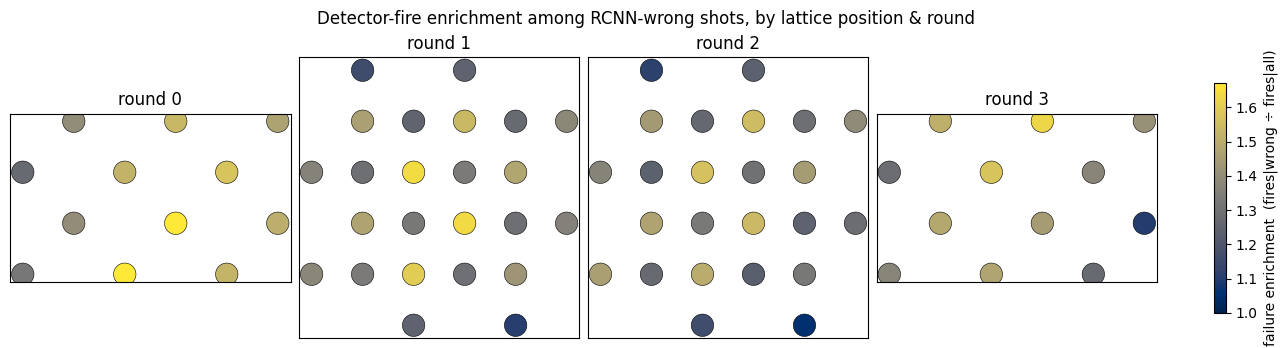

Most failure-enriched detectors:
  D 5  coords (x=4, y=8, round=0)  enrich=1.70  (fires 20.9% | wrong vs 12.3% | all)
  D 7  coords (x=6, y=6, round=0)  enrich=1.70  (fires 21.6% | wrong vs 12.7% | all)
  D21  coords (x=4, y=4, round=1)  enrich=1.64  (fires 25.1% | wrong vs 15.3% | all)
  D26  coords (x=6, y=6, round=1)  enrich=1.64  (fires 25.4% | wrong vs 15.5% | all)
  D66  coords (x=6, y=2, round=3)  enrich=1.63  (fires 16.5% | wrong vs 10.2% | all)
  D31  coords (x=4, y=8, round=1)  enrich=1.60  (fires 23.4% | wrong vs 14.7% | all)
  D 8  coords (x=8, y=4, round=0)  enrich=1.57  (fires 20.1% | wrong vs 12.8% | all)
  D64  coords (x=4, y=4, round=3)  enrich=1.57  (fires 16.7% | wrong vs 10.6% | all)


In [23]:
fail = ~rcnn_ok
rate_all  = det_evts.mean(0)
rate_fail = det_evts[fail].mean(0)
enrich = rate_fail / np.clip(rate_all, 1e-9, None)

xs = np.array([DET_COORDS[i][0] for i in range(CIRC.num_detectors)])
ys = np.array([DET_COORDS[i][1] for i in range(CIRC.num_detectors)])
ts = np.array([int(DET_COORDS[i][2]) for i in range(CIRC.num_detectors)])
uniq_t = sorted(set(ts))

fig, axes = plt.subplots(1, len(uniq_t), figsize=(3.2*len(uniq_t), 3.4), constrained_layout=True)
if len(uniq_t) == 1: axes = [axes]
vmax = np.percentile(enrich, 98)
for ax, t in zip(axes, uniq_t):
    m = ts == t
    sc = ax.scatter(xs[m], ys[m], c=enrich[m], s=260, cmap='cividis',
                    vmin=1.0, vmax=vmax, edgecolors='k', linewidths=0.4)
    ax.set_title(f"round {t}"); ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(sc, ax=axes, shrink=0.8, label='failure enrichment  (fires|wrong ÷ fires|all)')
fig.suptitle("Detector-fire enrichment among RCNN-wrong shots, by lattice position & round")
plt.show()

top = np.argsort(enrich)[::-1][:8]
print("Most failure-enriched detectors:")
for i in top:
    print(f"  D{i:2d}  coords (x={DET_COORDS[i][0]:.0f}, y={DET_COORDS[i][1]:.0f}, round={int(DET_COORDS[i][2])})"
          f"  enrich={enrich[i]:.2f}  (fires {rate_fail[i]*100:.1f}% | wrong vs {rate_all[i]*100:.1f}% | all)")
